### **DBSCAN** (밀도 기반 군집화)

- 밀도 기반의 클러스터링 알고리즘으로, 데이터의 밀도를 이용하여 군집을 생성
- 데이터가 빽빽한(고밀도) 지역을 하나의 군집으로 생성하고 드문(저밀도) 지역은 노이즈(이상치)로 판단
- KMeans와는 다르게 군집의 개수를 지정할 필요 없다.
- 비선형 구조의 데이터에서도 군집 형성이 가능 (원형, 나선형 구조의 데이터에서 패턴 분석 가능)
- 노이즈를 판단함으로 이상치에 대한 자동 감지
- 스케일링을 일반적으로 사용 (Standard, min-max)

- **parameter**
    - `eps`
        - default : 0.5
        - 두 개의 샘플이 같은 군집으로 간주되기 위한 최대의 거리 (반경)
        - 스케일링이 된 데이터를 기준으로 한다면 eps는 최대 2정도로 설정
        - 스케일링이 되지 않은 데이터를 기준으로 한다면 eps는 feature 데이터 범위에 따라 값이 변한다.
    
    - `min_samples`
        - default : 5
        - 핵심점(core point)으로 판단하기 위한 sample의 개수 
    
    - `metric`
        - default : `euclidean`
        - 거리 계산 방식
    
    - `algorithm`
        - default : `auto`
        - 이웃 탐색 알고리즘
        - `auto` → 자동 선택. 데이터 특성에 따라 알고리즘 자동 선택
        - `brute` → 모든 점간의 거리를 계산 → 데이터의 개수가 적은 경우 사용
        - `kd_tree` → 저차원 데이터(20차원 이하)에서 매우 빠른 성능
        - `ball_tree` → 고차원 데이터에서 효율적인 거리 탐색(공간 분할 기반)
    
    - `leaf_size`
        - default : 30
        - Tree 알고리즘 사용하는 경우 리프의 크기를 지정 (미세한 성능을 조절할 때 사용)

- **속성**
    - `core_sample_indices_`
        - 핵심점 인덱스의 목록
    - `components_`
        - 핵심점 좌표 배열
    - `labels_`
        - 각 데이터의 군집 라벨 (노이즈는 -1)

- **메서드**
    - `fit()`
    - `predict()`


- **동작의 원리**
    1. 핵심점을 생성 (각 점에 대해서 이웃점의 개수를 계산)
    2. 경계점을 생성 (핵심점 근처에 데이터가 존재하지만 자신이 핵심이 아닌 경우)
    3. 노이즈점을 생성 (어떠한 군집에도 속하지 않은 데이터)
    4. 핵심점에서 시작해서 이웃을 계속 측정하여 확장하면서 군집을 형성


- **파라미터 튜닝 팁**
    - 너무 많은 노이즈가 생성된다?
        - `eps`를 증가시키거나 `min_samples` 감소
    - 군집이 너무 뭉치는 경우
        - `eps` 감소
    - 너무 고차원인 경우
        - 차원 축소를 통해서 고차원 데이터를 저차원으로 변경하고 사용
    - 속도가 너무 느리다
        - `algorithm`을 `kd_tree`로 변경하거나 `n_jobs`를 -1로 변경

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [2]:
body = pd.read_csv('../data/bodyPerformance.csv')

In [3]:
obj_cols = body.select_dtypes('object').columns
le = LabelEncoder()

for col in obj_cols:
    body[col] = le.fit_transform(body[col])

C:\Users\hkssn\AppData\Local\Temp\ipykernel_23816\1183030952.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = body.select_dtypes('object').columns


In [4]:
X = body.drop(['class'], axis = 1)
y1 = body['class']
y2 = body['gender']

In [5]:
# 스케일링

X_std = StandardScaler().fit_transform(X)

In [6]:
# X 데이터에서 k 번째 최근접 이웃의 거리를 계산
# NearestNeighbors :기존 데이터들 중에서 거리상 가장 가까운 k개의 이웃 데이터를 찾아내는 역할
# n_neighbors 매개변수 → 몇번째 이웃 데이터를 찾아낼 것인가

nbrs = NearestNeighbors(n_neighbors=10).fit(X_std)

# kneighbors() → 특정 데이터와 가장 가까운 이웃들 간의 '거리'와 '위치(인덱스)'를 직접 계산해서 반환해주는 함수

distances, idxs = nbrs.kneighbors(X_std)

In [7]:
# 각각의 거리 데이터에서 10번째 이웃의 거리만 추출
kth_list = np.sort(distances[:, -1])

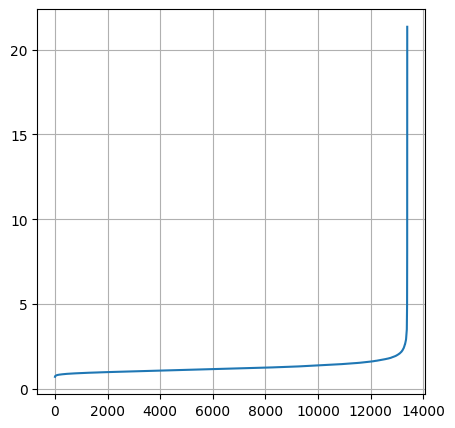

In [8]:
plt.figure(figsize=(5, 5))
plt.plot(kth_list)
plt.grid(True)
plt.show()

In [9]:
# eps → 꺾이는 지점 (기울기 변화가 큰 지점을 eps)

diffs = np.diff(kth_list)
diffs

array([2.05561147e-02, 4.17030652e-03, 2.95242168e-03, ...,
       1.63507109e+00, 9.98022906e+00, 3.23074202e+00], shape=(13392,))

In [10]:
eps_ = np.where(diffs>0.05)[0]

In [11]:
eps_

array([13357, 13370, 13371, 13374, 13376, 13378, 13380, 13382, 13383,
       13384, 13385, 13386, 13387, 13388, 13389, 13390, 13391])

In [12]:
print('급변하는 인덱스의 값: ', eps_)
print('대략적인 eps의 최적값: ', kth_list[eps_[0]])

급변하는 인덱스의 값:  [13357 13370 13371 13374 13376 13378 13380 13382 13383 13384 13385 13386
 13387 13388 13389 13390 13391]
대략적인 eps의 최적값:  3.051458810772378


In [13]:
# body data를 scaling 했을 때 최적의 거리는 3으로 지정하면 군집이 깔끔하게 완성 → 3
db = DBSCAN(
    eps = 1.7,
    min_samples = 10,
    n_jobs = -1
)

# 모델 학습 및 예측
labels = db.fit_predict(X_std)

In [14]:
set(labels)

{np.int64(-1), np.int64(0), np.int64(1)}

In [15]:
# 노이즈를 제외한 labels의 개수를 확인
np.sum(labels != -1)

np.int64(13052)

In [16]:
# 검증 지표
# 노이즈 제외하고 검증

flag = labels != -1
sil = silhouette_score(X_std[flag], labels[flag])
ari = adjusted_rand_score(y1, labels)
print(sil)
print()
print(ari)

0.3466129480317822

0.0049927528548928055


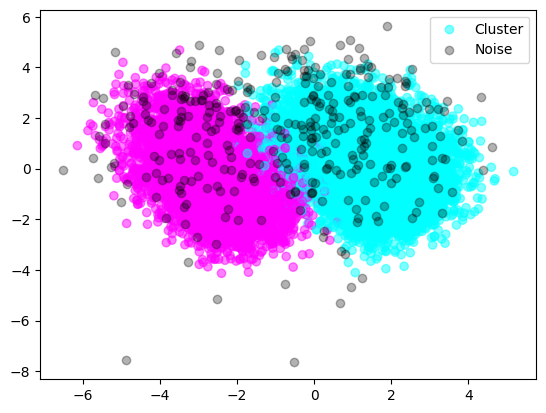

In [17]:
# PCA를 이용하여 2차원으로 차원 축소하고 그래프 시각화
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

# 노이즈 / 비노이즈 부분을 다르게 표시
non_noise = labels != -1

# 비노이즈 산점도 그래프 표시
plt.scatter(X_pca[non_noise, 0], X_pca[non_noise, 1], \
            c = labels[non_noise], cmap = 'cool', label = 'Cluster', alpha = 0.5)

# 노이즈 산점도 그래프 표시
plt.scatter(X_pca[~non_noise, 0], X_pca[~non_noise, 1], c = 'black', label = 'Noise', alpha = 0.3)

plt.legend()
plt.show()

In [18]:
# eps를 줄였을 때 노이즈의 개수가 실제로 변하는가?

db2 = DBSCAN(
    eps = 1.3,
    min_samples = 10,
    n_jobs = -1
)

labels2 = db2.fit_predict(X_std)

In [19]:
np.sum(labels2 == -1)

np.int64(1943)

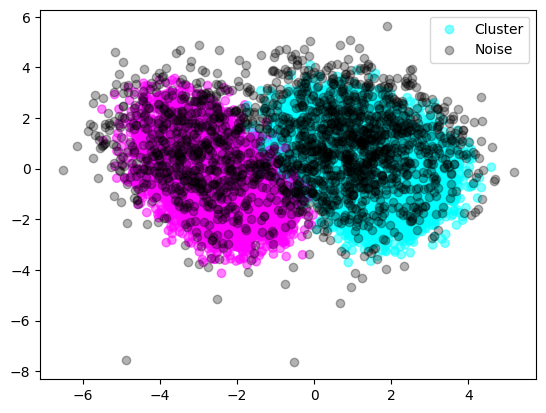

In [20]:
# 노이즈 / 비노이즈 부분을 다르게 표시
non_noise = labels2 != -1

# 비노이즈 산점도 그래프 표시
plt.scatter(X_pca[non_noise, 0], X_pca[non_noise, 1], \
            c = labels[non_noise], cmap = 'cool', label = 'Cluster', alpha = 0.5)

# 노이즈 산점도 그래프 표시
plt.scatter(X_pca[~non_noise, 0], X_pca[~non_noise, 1], c = 'black', label = 'Noise', alpha = 0.3)

plt.legend()
plt.show()